In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [22]:
df = pd.read_csv('D:weight-height.csv')
df

,Gender,Height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796
...,...,...
9995,Female,66.172652
9996,Female,67.067155
9997,Female,63.867992
9998,Female,69.034243


# using s.d

In [23]:
df1 = dataset1[['Gender','Height']]

In [24]:
df1.shape

(10000, 2)

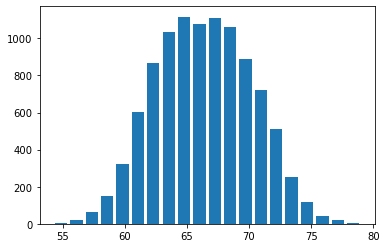

In [25]:
plt.hist(df.Height,bins=20,rwidth=0.8)
plt.show()

In [26]:
df.Height.min()

54.26313333

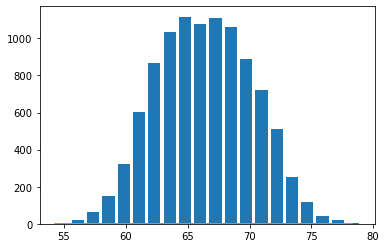

In [27]:
plt.hist(df1.Height,bins=20,rwidth=0.8)
reg= np.arange(df1.Height.min(),df1.Height.max())
plt.plot(reg,norm.pdf(reg,df1.Height.mean(),df1.Height.std()))

In [28]:
df1.Height.mean()

66.3675597548656

In [29]:
df1.Height.std()

3.847528120795573

In [30]:
upper = df1.Height.mean()+3*df1.Height.std()
upper

77.91014411725232

In [31]:
lower = df1.Height.mean()-3*df1.Height.std()
lower

54.824975392478876

In [32]:
df2 = df1[(df.Height>upper)|(df.Height<lower)]
df2

,Gender,Height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


In [33]:
df3 = df1[(df1.Height<upper) & (df1.Height>lower)]
df3

,Gender,Height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796
...,...,...
9995,Female,66.172652
9996,Female,67.067155
9997,Female,63.867992
9998,Female,69.034243


(array([   8.,   32.,   71.,  164.,  313.,  574.,  797.,  919., 1013.,
        1002., 1006., 1025.,  930.,  727.,  632.,  388.,  225.,  104.,
          37.,   26.]),
 array([54.87372753, 56.00740047, 57.14107341, 58.27474635, 59.40841929,
        60.54209223, 61.67576517, 62.80943811, 63.94311105, 65.07678399,
        66.21045693, 67.34412988, 68.47780282, 69.61147576, 70.7451487 ,
        71.87882164, 73.01249458, 74.14616752, 75.27984046, 76.4135134 ,
        77.54718634]),
 <BarContainer object of 20 artists>)

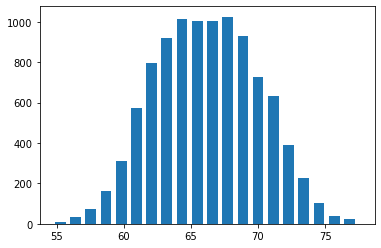

In [34]:
plt.hist(df3["Height"],bins=20,width=0.8)

# using z score

In [40]:
df1['zscore'] = (df1.Height - df1.Height.mean())/df1.Height.std()
df1



,Gender,Height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375
...,...,...,...
9995,Female,66.172652,-0.050658
9996,Female,67.067155,0.181830
9997,Female,63.867992,-0.649655
9998,Female,69.034243,0.693090


In [41]:
df1[df1['zscore']>3]

,Gender,Height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [42]:
df1[df1['zscore']<-3]

,Gender,Height,zscore
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [43]:
df2[(df1.zscore<-3)| (df1.zscore>3)]

<ipython-input-43-69bd4004ef69>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2[(df1.zscore<-3)| (df1.zscore>3)]


,Gender,Height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133
